<a href="https://colab.research.google.com/github/anilkhadka999/churn-analysis/blob/main/Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Analysis Project**


## Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Load Dataset

In [7]:
url ="https://raw.githubusercontent.com/anilkhadka999/churn-analysis/main/Dataset_ATS_v2%20(1).csv"

df = pd.read_csv(url)
df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [8]:
TARGET_COL = "Churn"

In [9]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 10)

Columns:
['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'MonthlyCharges', 'Churn']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,2,No,4072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,2,DSL,3947,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract,7043,3,Month-to-month,3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyCharges,7043.0,NaN,NaN,NaN,64.758768,30.09165,18.0,36.0,70.0,90.0,119.0
Churn,7043,2,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Inspect Dataset

In [12]:
# missing values
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing values:\n")
print(missing if len(missing) else "No missing values found.")

Missing values:

No missing values found.


In [13]:
# duplicates
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 302


In [14]:
# unique values in object columns
object_cols = df.select_dtypes(include="object").columns.tolist()

for col in object_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False).head(10))


gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

InternetService:
InternetService
DSL            3947
Fiber optic    3096
Name: count, dtype: int64

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# Data cleaning

In [15]:
# Clean string columns
df_clean = df.copy()

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )

In [16]:
# Remove duplicates
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
after = df_clean.shape[0]

print(f"Removed {before - after} duplicate rows.")

Removed 302 duplicate rows.


In [17]:
# Check invalid target rows
invalid_target = df_clean[TARGET_COL].isna().sum()
print("Rows with invalid/missing target:", invalid_target)

Rows with invalid/missing target: 0


In [18]:
summary = pd.DataFrame({
    "dtype": df_clean.dtypes.astype(str),
    "missing_count": df_clean.isna().sum(),
    "missing_pct": (df_clean.isna().mean() * 100).round(2),
    "n_unique": df_clean.nunique(dropna=True)
}).sort_values(by="missing_pct", ascending=False)

summary

,dtype,missing_count,missing_pct,n_unique
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,2
InternetService,object,0,0.0,2
Contract,object,0,0.0,3
MonthlyCharges,int64,0,0.0,101
Churn,object,0,0.0,2


# Data exploration

In [19]:
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({1: 'Yes', 0: 'No'}).astype(object)
print(df_clean['SeniorCitizen'].value_counts())
print(f"New dtype for SeniorCitizen: {df_clean['SeniorCitizen'].dtype}")

SeniorCitizen
No     5611
Yes    1130
Name: count, dtype: int64
New dtype for SeniorCitizen: object


In [20]:
# Separate numeric and categorical columns

numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET_COL]

categorical_cols = [c for c in df_clean.columns if c not in numeric_cols + [TARGET_COL]]

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['tenure', 'MonthlyCharges']
Categorical columns: ['gender', 'SeniorCitizen', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract']


In [21]:
# Numerical summary
df_clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,6741.0,32.945112,24.333994,0.0,10.0,30.0,56.0,72.0
MonthlyCharges,6741.0,65.843495,29.680059,18.0,41.0,71.0,90.0,119.0


In [22]:
# Categorical summary
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts(dropna=False))


--- gender ---
gender
Male      3393
Female    3348
Name: count, dtype: int64

--- SeniorCitizen ---
SeniorCitizen
No     5611
Yes    1130
Name: count, dtype: int64

--- Dependents ---
Dependents
No     4690
Yes    2051
Name: count, dtype: int64

--- PhoneService ---
PhoneService
Yes    6068
No      673
Name: count, dtype: int64

--- MultipleLines ---
MultipleLines
No     3895
Yes    2846
Name: count, dtype: int64

--- InternetService ---
InternetService
DSL            3776
Fiber optic    2965
Name: count, dtype: int64

--- Contract ---
Contract
Month-to-month    3653
Two year          1649
One year          1439
Name: count, dtype: int64


In [23]:
# Target

print(df_clean[TARGET_COL].value_counts(normalize=True))


Churn
No     0.734312
Yes    0.265688
Name: proportion, dtype: float64


# Data visualization

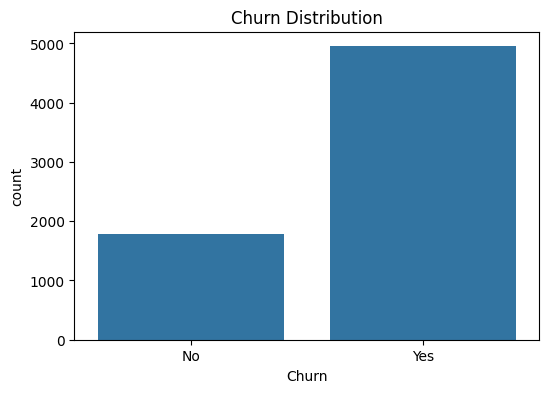

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(x=TARGET_COL, data=df_clean)
plt.title("Churn Distribution")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

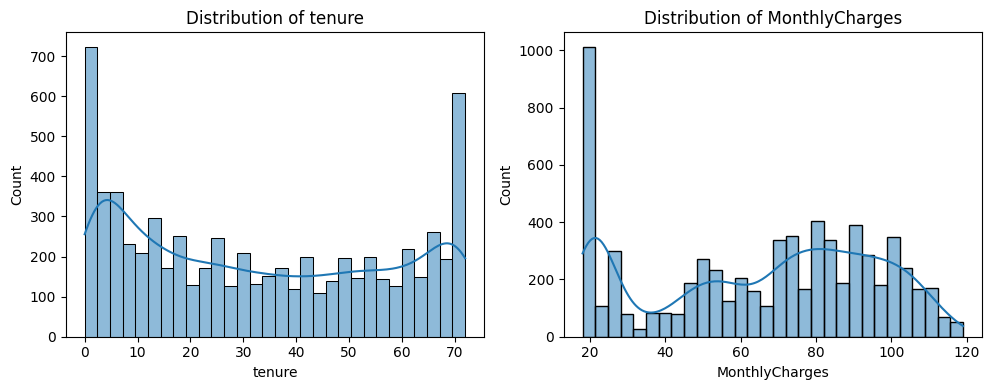

In [25]:
num_plots = len(numeric_cols)
n_cols = 3
n_rows = (num_plots + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_clean[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()

plt.show()

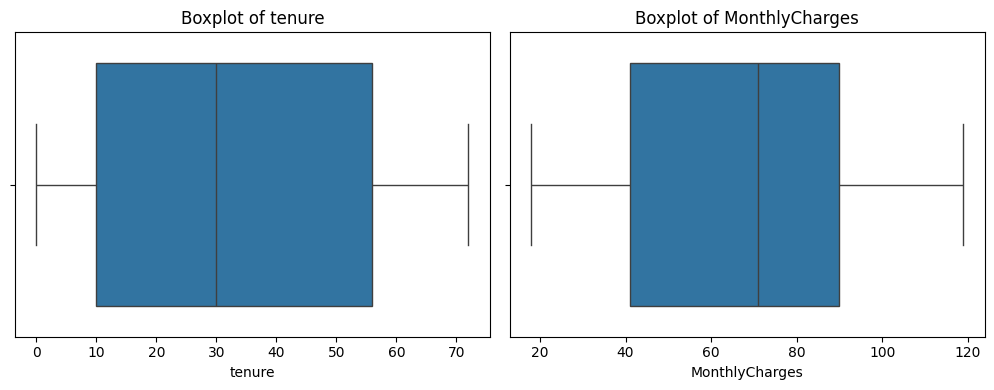

In [26]:
num_plots = len(numeric_cols)
n_cols = 3
n_rows = (num_plots + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
plt.show()

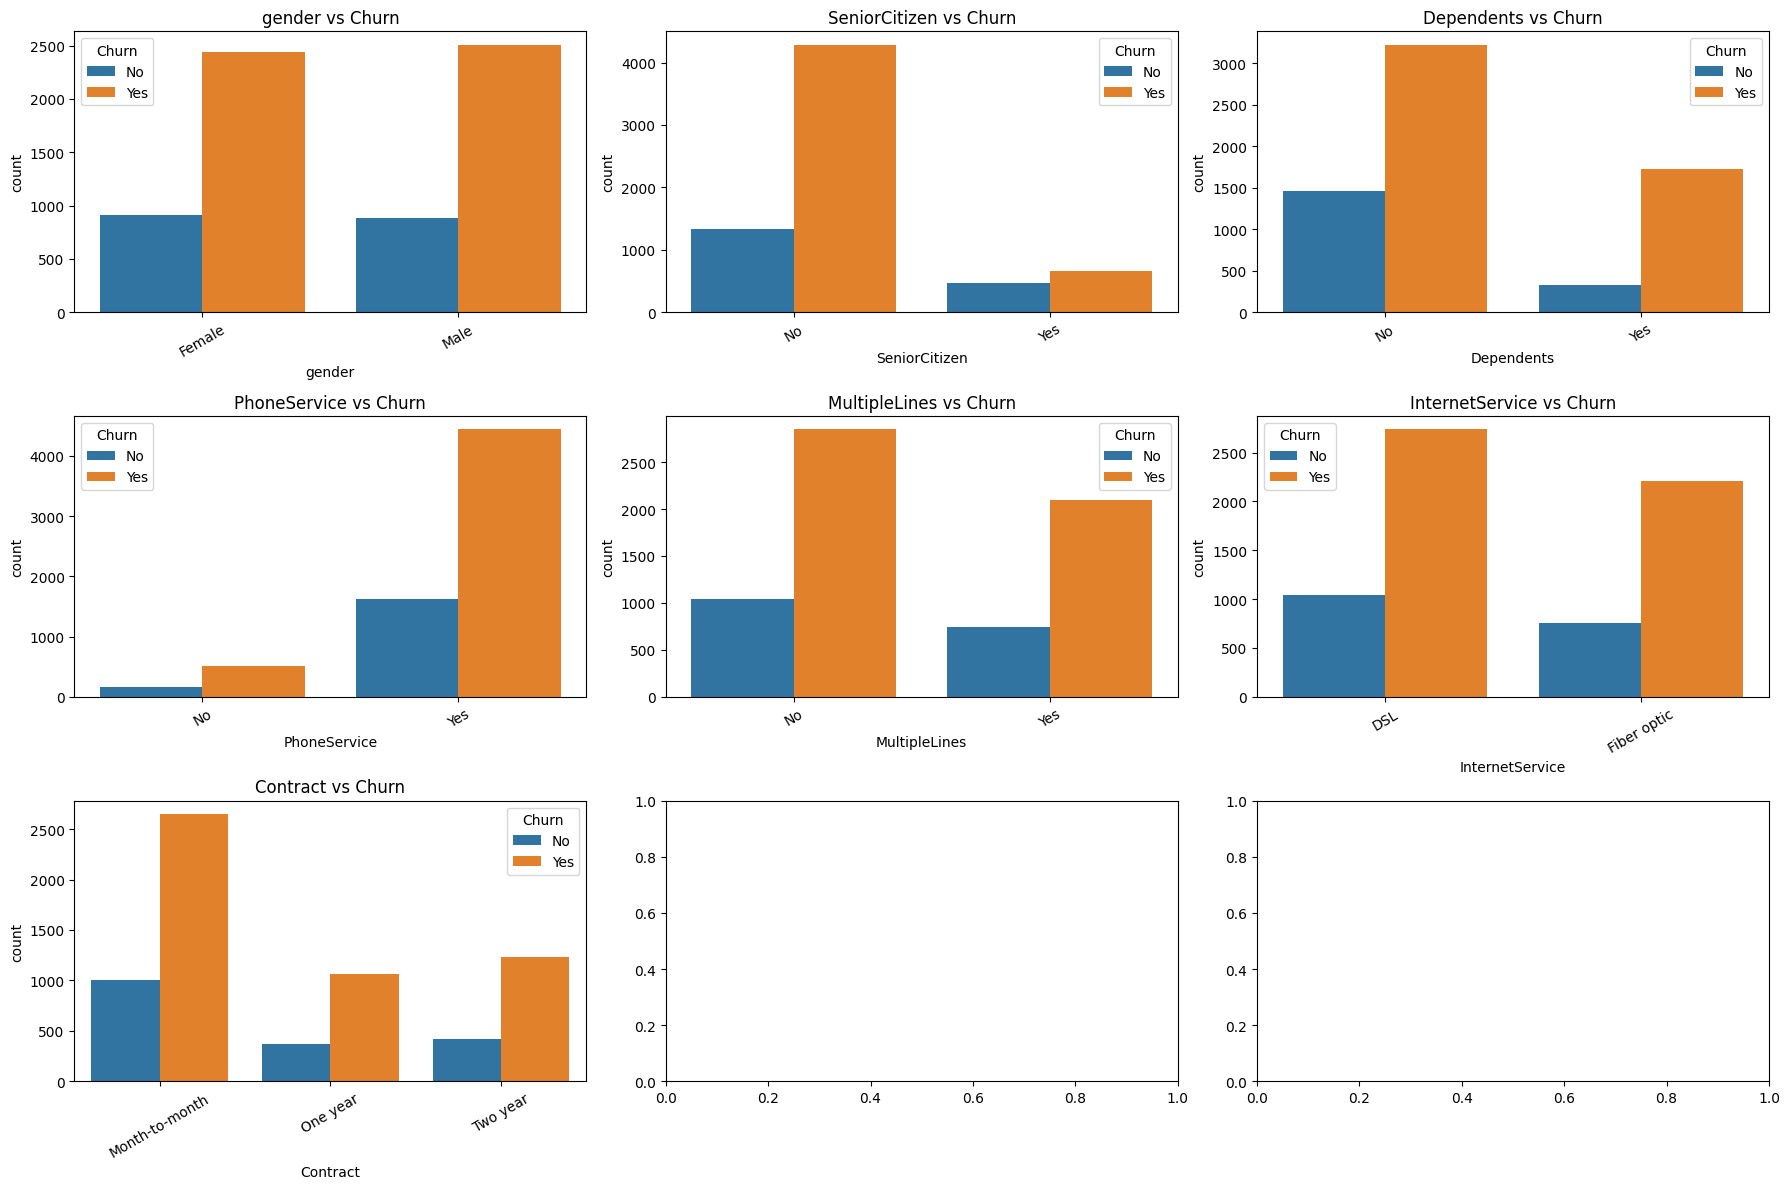

In [27]:
num_plots = len(categorical_cols)
n_cols = 3
n_rows = (num_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(data=df_clean, x=col, hue=TARGET_COL, ax=axes[i])
        axes[i].set_title(f"{col} vs Churn")
        axes[i].tick_params(axis='x', rotation=30)
        if axes[i].get_legend() is not None:
            axes[i].legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

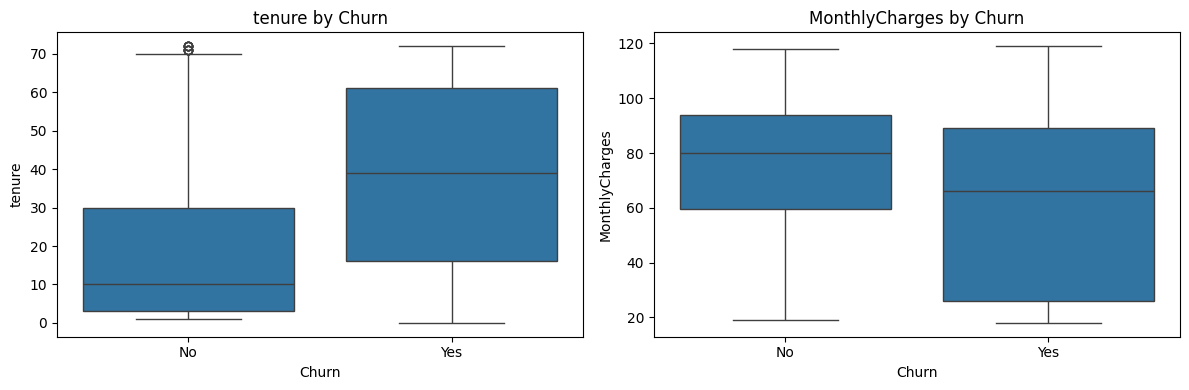

In [28]:

num_plots = len(numeric_cols)
n_cols = 2
n_rows = (num_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.boxplot(data=df_clean, x=TARGET_COL, y=col, ax=axes[i])
        axes[i].set_title(f"{col} by Churn")
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(["No", "Yes"])

plt.tight_layout()
plt.show()

# Encoding

In [29]:
# Encode target column
df_clean[TARGET_COL] = df_clean[TARGET_COL].map({
    "Yes": 1,
    "No": 0,
    "yes": 1,
    "no": 0
})

print(df_clean[TARGET_COL].value_counts(dropna=False))

Churn
0    4950
1    1791
Name: count, dtype: int64


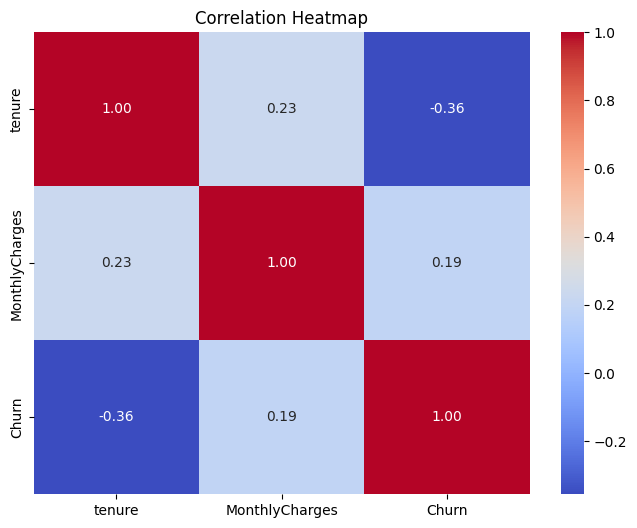

In [30]:
if numeric_cols:
    plt.figure(figsize=(8, 6))
    sns.heatmap(df_clean[numeric_cols + [TARGET_COL]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

In [31]:
# Separate features and target

X = df_clean.drop(TARGET_COL, axis=1)
y = df_clean[TARGET_COL]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (6741, 9)
Target shape: (6741,)


In [32]:
# Encode categorical feature columns

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("Encoded feature shape:", X_encoded.shape)
X_encoded.head()

Encoded feature shape: (6741, 10)


,tenure,MonthlyCharges,gender_Male,SeniorCitizen_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
0,1,25,False,False,False,False,False,False,False,False
1,41,25,True,False,False,True,False,False,True,False
2,52,19,False,False,True,True,False,False,False,False
3,1,76,False,False,False,True,False,False,True,False
4,67,51,True,False,False,True,False,True,False,False


# Train-test split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train.head()

X_train shape: (5392, 10)
X_test shape : (1349, 10)
y_train shape: (5392,)
y_test shape : (1349,)


,tenure,MonthlyCharges,gender_Male,SeniorCitizen_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
4349,56,110,False,False,True,True,True,True,False,False
953,63,59,False,False,False,True,False,False,False,False
5550,53,94,False,False,False,True,False,False,True,False
289,72,114,True,False,True,True,False,False,False,False
3292,9,76,True,False,False,True,False,False,False,False


# Scaling

In [34]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,tenure,MonthlyCharges,gender_Male,SeniorCitizen_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,Contract_One year,Contract_Two year
4349,0.944773,1.486201,False,False,True,True,True,True,False,False
953,1.232687,-0.234838,False,False,False,True,False,False,False,False
5550,0.821382,0.946267,False,False,False,True,False,False,True,False
289,1.602861,1.621184,True,False,True,True,False,False,False,False
3292,-0.988360,0.338842,True,False,False,True,False,False,False,False


In [35]:
print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape :', X_test_scaled.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train_scaled shape: (5392, 10)
X_test_scaled shape : (1349, 10)
y_train shape: (5392,)
y_test shape : (1349,)


In [36]:
X_train_scaled.to_csv("X_train_scaled.csv", index=False)
X_test_scaled.to_csv("X_test_scaled.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [37]:
preprocessed_df = pd.concat([X_train_scaled, y_train], axis=1)
preprocessed_test_df = pd.concat([X_test_scaled, y_test], axis=1)

full_preprocessed_df = pd.concat([preprocessed_df, preprocessed_test_df], axis=0)
full_preprocessed_df = full_preprocessed_df.sort_index()

full_preprocessed_df.to_csv("preprocessed_dataset.csv", index=False)

# K-Means clustering - Elbow and Silhouette Method

In [38]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

X = df_clean[["tenure", "MonthlyCharges"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

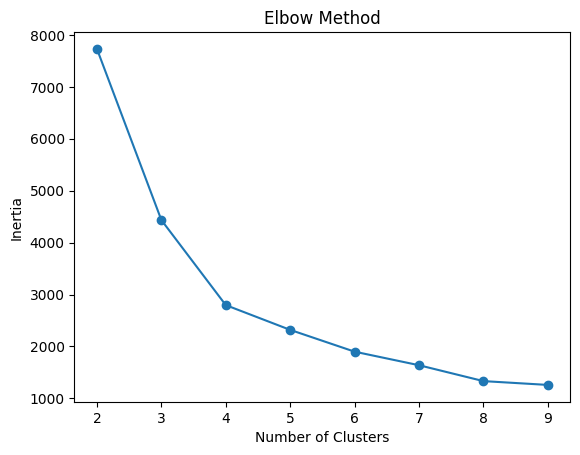

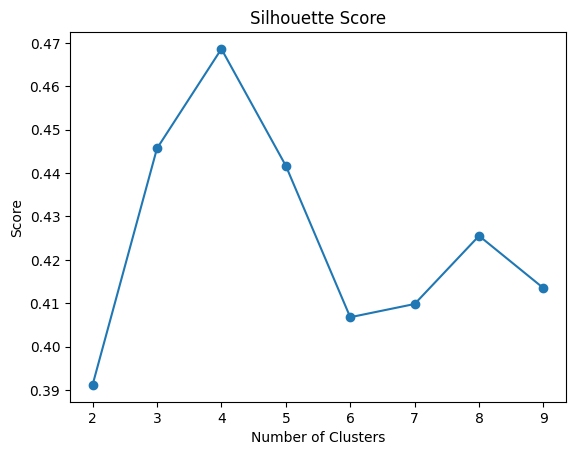

In [39]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

inertia = []
silhouette = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_scaled, kmeans.labels_))

# Elbow plot
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# Silhouette plot
plt.plot(K_range, silhouette, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")
plt.show()

CHOOSING K=4 based on above plots

# Train Final K-means Model

In [63]:
from sklearn.cluster import KMeans
import joblib
import os

kmeans = KMeans(n_clusters=4, random_state=42)
df_clean["Cluster"] = kmeans.fit_predict(X_scaled)
X = df_clean[["tenure", "MonthlyCharges"]]
df_clean["Churn"] = df_clean["Churn"].replace({ "Yes": 1, "No": 0 })
cluster_summary = df_clean.groupby("Cluster").agg({ "tenure": "mean", "MonthlyCharges": "mean", "SeniorCitizen": "mean", "Churn": "mean" }).round(2)
print(cluster_summary)

# Create the directory if it doesn't exist
os.makedirs("Clustering_Analysis", exist_ok=True)

joblib.dump(kmeans, "Clustering_Analysis/kmeans_model.pkl")
joblib.dump(scaler, "Clustering_Analysis/scaler.pkl")

         tenure  MonthlyCharges  SeniorCitizen  Churn
Cluster                                              
0         11.34           33.76           0.08   0.25
1         14.93           81.66           0.24   0.49
2         58.58           93.04           0.22   0.16
3         54.17           34.67           0.08   0.05


['Clustering_Analysis/scaler.pkl']

# Clusters Visualisation

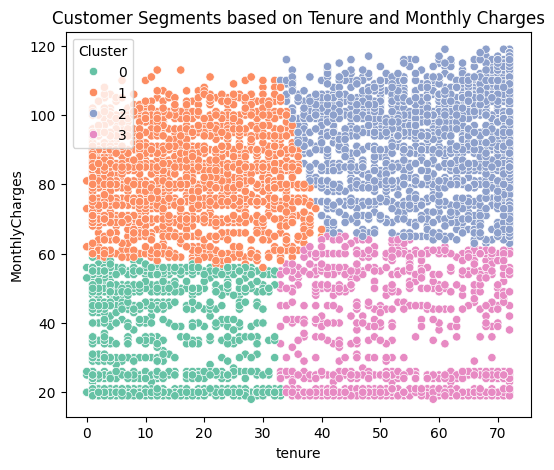

In [49]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.scatterplot(
    x=df_clean["tenure"],
    y=df_clean["MonthlyCharges"],
    hue=df_clean["Cluster"],
    palette="Set2"
)
plt.title("Customer Segments based on Tenure and Monthly Charges")
plt.show()

The clustering results indicate four customer segments with varying degrees of separation. While some clusters are clearly distinguishable, others exhibit overlap, suggesting shared characteristics among customers.

In [74]:
cluster_labels = {
    0: "Low Value New Customers",
    1: "At-Risk High Spenders",
    2: "High Value At-Risk Customers",
    3: "Loyal Low-Cost Customers"
}
df_clean["Cluster_Label"] = df_clean["Cluster"].map(cluster_labels)

df_clean[["Cluster", "Cluster_Label"]].head()

,Cluster,Cluster_Label
0,0,Low Value New Customers
1,3,Loyal Low-Cost Customers
2,3,Loyal Low-Cost Customers
3,1,At-Risk High Spenders
4,3,Loyal Low-Cost Customers


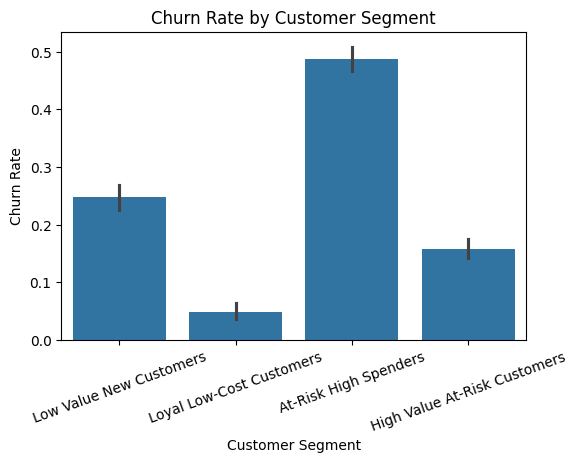

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x="Cluster_Label", y="Churn", data=df_clean)

plt.title("Churn Rate by Customer Segment")
plt.ylabel("Churn Rate")
plt.xlabel("Customer Segment")
plt.xticks(rotation=20)
plt.show()

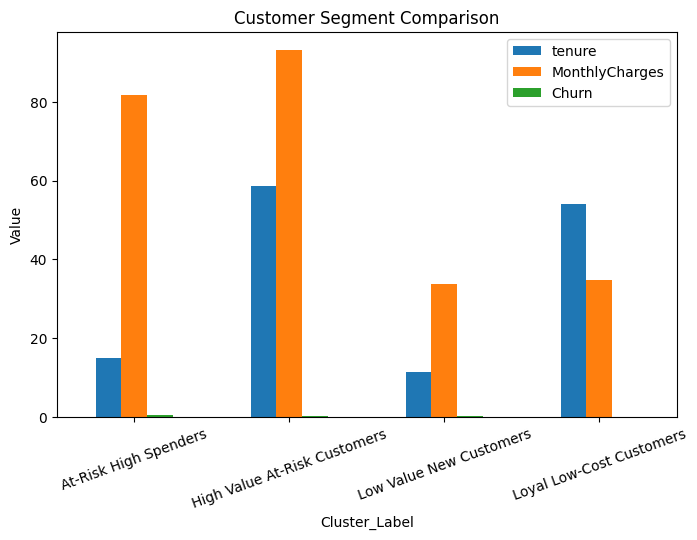

In [76]:
cluster_summary = df_clean.groupby("Cluster_Label").agg({
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "Churn": "mean"
}).reset_index()

cluster_summary.plot(x="Cluster_Label", kind="bar", figsize=(8,5))
plt.title("Customer Segment Comparison")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.show()

Labeling Visualisation

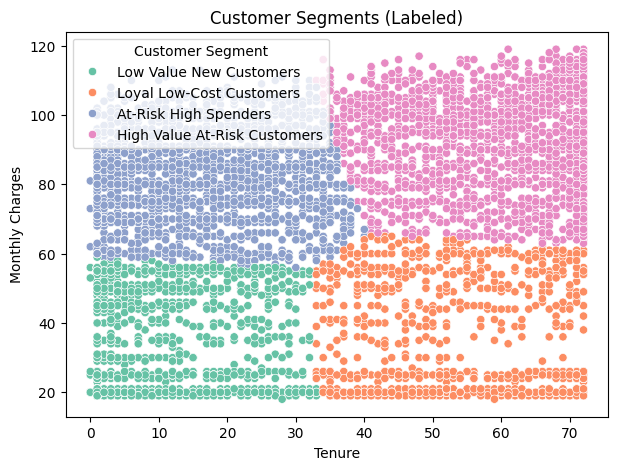

In [77]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df_clean["tenure"],
    y=df_clean["MonthlyCharges"],
    hue=df_clean["Cluster_Label"],
    palette="Set2"
)

plt.title("Customer Segments (Labeled)")
plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.legend(title="Customer Segment")
plt.show()

<Axes: ylabel='Cluster_Label'>

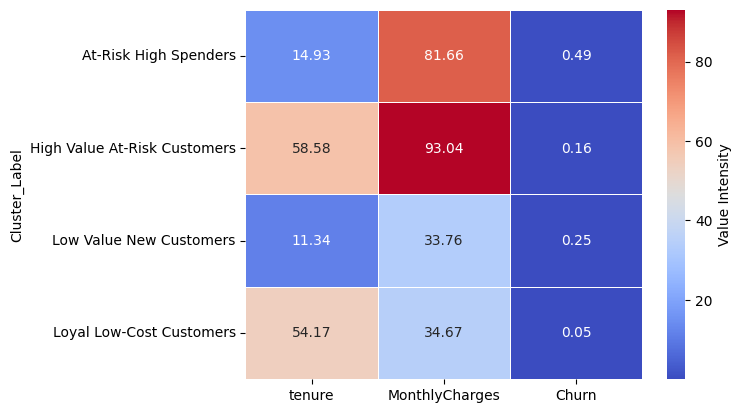

In [80]:
heatmap_data = cluster_summary.set_index('Cluster_Label')
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Value Intensity"})

In [81]:
cluster_summary = df_clean.groupby("Cluster_Label")[["tenure", "MonthlyCharges", "Churn"]].mean().round(2)
print(cluster_summary)

                              tenure  MonthlyCharges  Churn
Cluster_Label                                              
At-Risk High Spenders          14.93           81.66   0.49
High Value At-Risk Customers   58.58           93.04   0.16
Low Value New Customers        11.34           33.76   0.25
Loyal Low-Cost Customers       54.17           34.67   0.05


### Identifying Critical Clusters
By sorting our clusters by churn rate, we can pinpoint which segment is most likely to leave and therefore most critical for retention strategies.

In [82]:
# Find the cluster with the highest churn rate
critical_cluster = cluster_summary.sort_values(by='Churn', ascending=False)

print("Clusters ranked by Churn Risk:")
display(critical_cluster)

most_critical = critical_cluster.index[0]
print(f"\nThe most critical cluster for churn reduction is: {most_critical}")

Clusters ranked by Churn Risk:


,tenure,MonthlyCharges,Churn
Cluster_Label,,,
At-Risk High Spenders,14.93,81.66,0.49
Low Value New Customers,11.34,33.76,0.25
High Value At-Risk Customers,58.58,93.04,0.16
Loyal Low-Cost Customers,54.17,34.67,0.05



The most critical cluster for churn reduction is: At-Risk High Spenders
